(04-19-momentum)=

# Jegadeesh-Titman, Carhart en momentum crashes

```{admonition} Waar we zijn in het verhaal
:class: important

**Jaartal.** 1993–2017, van Jegadeesh en Titman tot de volatility-managed portfolios.

**Wat we al weten.** [Fama en French](#04-18-fama-french) vatten size en waarde samen
in een driefactormodel dat de anomalieën uit [](#03-16-vroege-anomalieen) grotendeels
verklaart. De filterregels uit [](#02-06-efficiente-markten) vonden in de tijdreeks van
prijzen niets wat na kosten overbleef. Eén regelmaat bleef over: aandelen die het het
afgelopen jaar goed deden, blijven het de maanden daarna beter doen, en het
driefactormodel ziet dat niet.

**Welke vraag staat open.** Is de voortzetting van relatieve rendementen een beloning
voor risico, een vergissing van beleggers, of een combinatie die alleen zichtbaar
wordt als je naar het tweede moment kijkt?
```

## Overzicht

In 1993 publiceerden Narasimhan Jegadeesh en Sheridan Titman een eenvoudige toets:
sorteer aandelen op hun rendement van de afgelopen drie tot twaalf maanden, koop de
winnaars, verkoop de verliezers, en houd dat drie tot twaalf maanden vast
{cite}`JegadeeshTitman1993`. Over 1965–1989 leverde dat ongeveer een procent per
maand op. Drie jaar later schreven Fama en French dat het onvermogen om deze
voortzetting te verklaren de "main embarassment" [sic] van hun driefactormodel was
{cite}`FamaFrench1996`, en Carhart voegde het verschil tussen winnaars en verliezers
als vierde factor toe om beleggingsfondsen te beoordelen {cite}`Carhart1997`. Sindsdien
heet de strategie *momentum* (de neiging van relatieve winnaars om winnaars te blijven)
en de factor WML (*winners minus losers*) of UMD (*up minus down*).

Momentum definieert dit deel van het tijdvak omdat het de zuiverste vorm is van motief
3: een feit zonder theorie. Size en waarde lieten zich nog lezen als risico dat het
CAPM miste; momentum volgde uit geen enkel evenwichtsmodel en overleefde toch elke
toets buiten de oorspronkelijke steekproef: na 1990 {cite}`JegadeeshTitman2001`, in
Europa {cite}`Rouwenhorst1998`, in industrieën {cite}`MoskowitzGrinblatt1999` en in
acht markten en activaklassen tegelijk {cite}`AsnessMoskowitzPedersen2013`. De
concurrerende theorieën kwamen daarna, zowel uit de gedragseconomie als uit de
risicohoek.

Het tweede deel van het verhaal gaat over het tweede moment. Momentum heeft zeldzame,
enorme crashes, in 1932 en 2009, precies wanneer de markt na een diepe val herstelt
{cite}`DanielMoskowitz2016`. Barroso en Santa-Clara lieten zien dat het risico van
momentum voorspelbaar is, en dat een strategie die haar blootstelling omgekeerd
evenredig met de voorspelde volatiliteit schaalt, de Sharpe-ratio bijna verdubbelt
{cite}`BarrosoSantaClara2015`. Dat idee werd algemeen: volatility-managed portfolios
{cite}`MoreiraMuir2017`. We leiden af waar momentumwinst vandaan komt, waarom de bèta
van WML na een beurscrash negatief wordt, en wanneer schalen met volatiliteit de
Sharpe-ratio verhoogt. Aan het eind repliceren we het winnaars-min-verliezersrendement
en de alfa's over 1965–1989, tabel 3 van Barroso en Santa-Clara, en de crashes van 1932
en 2009.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm
from scipy import optimize, signal, stats

import hap
from hap import data as hap_data
hap.plotting.setup()

rng = np.random.default_rng(20240101)

## Intuïtie: waarom zou dit waar zijn?

De filterregel van Alexander uit [](#02-06-efficiente-markten) vraagt of een koers die
is gestegen, blijft stijgen; die vraag verdrinkt in de ruis van de markt. Jegadeesh en
Titman vroegen of een aandeel dat het *beter* deed dan andere aandelen, daarna ook
beter blijft doen. Door te sorteren verdwijnt de markt uit de vergelijking. Bekend was
dat relatieve rendementen op een maand en op drie tot vijf jaar
{cite}`DeBondtThaler1985` omkeren; op de horizon daartussen vonden zij voortzetting.

Een winnaar kan op drie manieren winnaar blijven, en ze voorspellen verschillende
dingen. Sommige aandelen hebben gewoon een hoger verwacht rendement; wie op vorig
rendement sorteert, sorteert dan een beetje op verwacht rendement, en de winnaars
blijven voor altijd winnen. Of nieuws wordt langzaam in de koers verwerkt, zodat een
koers die op goed nieuws steeg, nog even doorstijgt. Of de koers schiet na die
onderreactie door, en de overschrijding wordt later gecorrigeerd. Alleen het derde
verhaal voorspelt dat de winnaars van nu over twee tot vijf jaar verliezers zijn: op de
lange horizon gaan de verklaringen uit elkaar.

Dan de crashes. Na een jaar waarin de markt hard daalde, zijn de winnaars de aandelen
die het minst meebewogen en de verliezers die het sterkst meebewogen. WML is dan long
lage bèta en short hoge bèta: een positie tegen de markt. Herstelt de markt, dan
verliest WML veel, en omdat de verliezers na een crash vaak half failliete bedrijven
zijn waarvan de aandelen zich als opties gedragen, herstelt de short-kant explosief.
Zulke periodes kondigen zich aan: de volatiliteit van momentum is dan al hoog. Wie
naar een vaste doelvolatiliteit schaalt, stapt uit wanneer de crash het
waarschijnlijkst is, en omdat volatiliteit veel beter te meten is dan gemiddeld
rendement (motief 1), werkt dat beter dan een voorspelling van het rendement zelf.

## Toy-voorbeeld: vier aandelen, twaalf maanden

**Het signaal.** Vier aandelen A–D hebben de volgende maandrendementen (in procenten;
lege cellen zijn nul). Het signaal voor maand 13 is het samengestelde rendement over
maand 1 tot en met 11: de *12-1*-regel, die de laatste maand overslaat.

| aandeel | 1 | 2 | 3 | 4 | 5 | 6 | 7 | 8 | 9 | 10 | 11 | **12** | *13* |
|---|---|---|---|---|---|---|---|---|---|---|---|---|---|
| A |   | +10 |   |   | +10 |   |   | +10 |   |   |   | **0** | *+3* |
| B | +10 |   |   |   |   | +10 |   |   | −10 |   |   | **+2** | *+1* |
| C |   |   | −10 |   |   |   | −10 |   |   |   |   | **+40** | *−4* |
| D |   |   |   | −10 |   |   |   |   |   | −10 | +10 | **−5** | *−2* |

De 12-1-signalen zijn $1{,}1^3 - 1 = 33{,}1\%$ voor A, $1{,}1^2 \cdot 0{,}9 - 1 = 8{,}9\%$
voor B, $0{,}9^2 - 1 = -19{,}0\%$ voor C en $0{,}9^2 \cdot 1{,}1 - 1 = -10{,}9\%$ voor D. De
rangorde is A, B, D, C. Met de bovenste helft als winnaars en de onderste als
verliezers, elk gelijkgewogen, is het rendement van WML in maand 13

$$
R^{\mathrm{WML}}_{13} = \tfrac12(3 + 1) - \tfrac12(-4 - 2) = 2 + 3 = 5\% .
$$

**Waarom de laatste maand overslaan.** Neem maand 12 wel mee (de 12-0-regel). Dan is
het signaal van B $1{,}089 \cdot 1{,}02 - 1 = 11{,}08\%$, dat van C
$0{,}81 \cdot 1{,}40 - 1 = 13{,}4\%$ en dat van D $0{,}891 \cdot 0{,}95 - 1 = -15{,}4\%$. C,
dat elf maanden verloor en in maand 12 een sprong van 40% maakte, wordt nu een winnaar,
B een verliezer, en WML levert $\tfrac12(3 - 4) - \tfrac12(1 - 2) = 0\%$ op. Eén maand
rendement bevat veel tijdelijke prijsdruk en bid-ask-ruis die de volgende maand
omkeert; de 12-1-regel houdt het signaal van het afgelopen jaar en laat de
kortetermijnomkering buiten.

**De bèta na een marktdaling.** Nu vier andere aandelen zonder eigen risico, met
bèta's $0{,}5$, $0{,}8$, $1{,}2$ en $1{,}5$. In de vormingsperiode daalt de markt met
20%, dus de rendementen zijn $-10\%$, $-16\%$, $-24\%$ en $-30\%$. De winnaars zijn de
twee aandelen met de laagste bèta (gemiddeld $0{,}65$), de verliezers die met de
hoogste ($1{,}35$). WML heeft dus bèta $0{,}65 - 1{,}35 = -0{,}70$. Herstelt de markt
de volgende maand met 20%, dan is $R^{\mathrm{WML}} = -0{,}70 \cdot 20\% = -14\%$: een
crash, zonder dat er iets aan het momentumeffect is veranderd. Na een stijging van
20% zijn de winnaars juist de hoge bèta's en is de bèta van WML $+0{,}70$.

In [2]:
toy = pd.DataFrame(0.0, index=list("ABCD"), columns=range(1, 14))
toy.loc["A", [2, 5, 8]] = 0.10
toy.loc["B", [1, 6]], toy.loc["B", 9] = 0.10, -0.10
toy.loc["C", [3, 7]] = -0.10
toy.loc["D", [4, 10]], toy.loc["D", 11] = -0.10, 0.10
toy[12] = [0.00, 0.02, 0.40, -0.05]
toy[13] = [0.03, 0.01, -0.04, -0.02]


def wml_toy(months):
    """Signal over `months`, then the month-13 return of top-half minus bottom-half."""
    sig = (1 + toy[months]).prod(axis=1) - 1
    ranked = sig.sort_values(ascending=False).index
    return sig, toy.loc[ranked[:2], 13].mean() - toy.loc[ranked[2:], 13].mean()


sig_12_1, wml_12_1 = wml_toy(list(range(1, 12)))
sig_12_0, wml_12_0 = wml_toy(list(range(1, 13)))

betas = np.array([0.5, 0.8, 1.2, 1.5])
formation = betas * -0.20
winners, losers = np.argsort(formation)[2:], np.argsort(formation)[:2]
beta_wml = betas[winners].mean() - betas[losers].mean()

print("12-1:", sig_12_1.round(4).to_dict(), f"WML_13 = {wml_12_1:.4f}")
print("12-0:", sig_12_0.round(4).to_dict(), f"WML_13 = {round(wml_12_0, 12) + 0.0:.4f}")
print(f"bèta WML na marktdaling = {beta_wml:.2f}, rendement bij herstel van 20% = {beta_wml * 0.20:.3f}")
print("code == handberekening:",
      np.allclose([wml_12_1, wml_12_0, beta_wml, beta_wml * 0.20], [0.05, 0.0, -0.70, -0.14]))

12-1: {'A': 0.331, 'B': 0.089, 'C': -0.19, 'D': -0.109} WML_13 = 0.0500
12-0: {'A': 0.331, 'B': 0.1108, 'C': 0.134, 'D': -0.1535} WML_13 = 0.0000
bèta WML na marktdaling = -0.70, rendement bij herstel van 20% = -0.140
code == handberekening: True


## Theorie

### Constructie: J/K-strategieën, UMD en het vierfactormodel

Laat $R_{i,t+1}$ het rendement van aandeel $i$ in maand $t+1$ zijn. Het
*momentumsignaal* op het eind van maand $t$ is het samengestelde rendement over de $J$
maanden daarvoor, eventueel met een sprong van één maand:

```{math}
:label: eq-momentum-signaal
s_{i,t} = \prod_{j=1}^{J} \left(1 + R_{i,t-j}\right) - 1 .
```

Voor $J = 11$ is dit de 12-1-regel uit het toy-voorbeeld: de maanden $t-11$ tot en met
$t-1$, voor het rendement in maand $t+1$. French noemt dezelfde sortering *prior
12-2*, omdat hij terugtelt vanaf de houdmaand.

**Jegadeesh en Titman.** Zij sorteerden alle NYSE- en AMEX-aandelen op
[](#eq-momentum-signaal) met $J \in \{3, 6, 9, 12\}$ en vormden gelijkgewogen
decielportefeuilles, die ze $K \in \{3, 6, 9, 12\}$ maanden aanhielden. Om niet van
één vormingsmaand afhankelijk te zijn, overlappen de portefeuilles: in maand $t+1$ is
de strategie het gemiddelde van de $K$ WML-portefeuilles die op $t, t-1, \dots, t-K+1$
zijn gevormd,

```{math}
:label: eq-momentum-jk
R^{\mathrm{WML}}_{t+1} = \frac1K \sum_{k=0}^{K-1} \sum_i w_{i,t-k}\, R_{i,t+1},
\qquad
w_{i,t} = \frac{\mathbb{1}\{s_{i,t} \geq q_{0{,}9,t}\}}{n_t} - \frac{\mathbb{1}\{s_{i,t} \leq q_{0{,}1,t}\}}{n_t},
```

met $q_{p,t}$ het $p$-kwantiel van de signalen en $n_t$ het aantal aandelen per deciel.
De gewichten tellen op tot nul: WML is een *zero-cost*-portefeuille (zonder eigen
inleg), en haar rendement is een excess rendement. In hun tabel I, over januari 1965
tot december 1989, verdiende de 6/6-strategie $0{,}0095$ per maand ($t = 3{,}07$) zonder
sprong en $0{,}0110$ ($t = 3{,}61$) met een week tussen vorming en houden; de meest
winstgevende was 12/3, met $0{,}0131$ ($t = 3{,}74$) en $0{,}0149$ ($t = 4{,}28$)
{cite}`JegadeeshTitman1993`. De strategie verloor gemiddeld ongeveer 7% in elke januari
en verdiende 1,66% per maand daarbuiten. In *event time* (gemeten in maanden sinds de
vorming) liep het cumulatieve rendement op tot 9,5% na twaalf maanden en zakte het
terug tot ongeveer 4% na 36 maanden (hun tabel VII).

**UMD en Carhart.** De momentumfactor van Kenneth French wordt gebouwd zoals SMB en HML
in [de lecture over Fama en French](#04-18-fama-french): zes waardegewogen portefeuilles uit een dubbele sortering op
marktwaarde (mediaan) en prior 12-2 (30e en 70e NYSE-percentiel), en

```{math}
:label: eq-momentum-umd
\mathrm{UMD}_{t+1} = \tfrac12\left(\text{klein hoog} + \text{groot hoog}\right)_{t+1}
- \tfrac12\left(\text{klein laag} + \text{groot laag}\right)_{t+1} .
```

{cite:t}`Carhart1997` gebruikte een verwante factor, PR1YR: het gelijkgewogen gemiddelde
van de 30% aandelen met het hoogste elfmaandsrendement, één maand vertraagd, min dat van
de 30% laagste. Over juli 1963 tot december 1993 verdiende PR1YR gemiddeld 0,82% per
maand ($t = 4{,}46$, zijn tabel II). Zijn vierfactormodel voor de prestatie van een
fonds $p$,

```{math}
:label: eq-momentum-carhart
R^{e}_{p,t+1} = \alpha_p + \beta_{p,m}\, R^{e}_{m,t+1} + \beta_{p,s}\,\mathrm{SMB}_{t+1}
+ \beta_{p,h}\,\mathrm{HML}_{t+1} + \beta_{p,u}\,\mathrm{UMD}_{t+1} + \varepsilon_{p,t+1},
```

werd de standaard in de fondsliteratuur. Zijn conclusie over 1892 fondsen uit
1962–1993 was dat de "hot hands" van fondsen grotendeels het eenjarige momentumeffect
zijn, en dat gemeenschappelijke factoren en kosten de persistentie bijna volledig
verklaren; dat verhaal pakken we op in [de lecture over de industrie](#04-25-industrie).
Carharts model is geen evenwichtsmodel: UMD staat erin omdat het werkt.

### Waar komt momentumwinst vandaan?

*Waarom zou dit waar zijn?* Een strategie die koopt wat relatief is gestegen, verdient
geld als het rendement van een aandeel positief correleert met zijn eigen verleden.
Maar het verdient ook geld als aandelen gewoon blijvend verschillende verwachte
rendementen hebben: dan zijn de winnaars van gisteren gemiddeld de aandelen met een hoog
verwacht rendement, zonder dat er enige autocorrelatie is. En het *verliest* geld als
het ene aandeel het andere met vertraging volgt, omdat de achterblijver dan inhaalt.
{cite:t}`LoMacKinlay1990b` schreven die drie bronnen voor contrarian-strategieën uit;
{cite:t}`JegadeeshTitman1993` gebruikten dezelfde algebra voor momentum.

Neem de relative-strength-gewichten $w_{i,t} = \frac1N(R_{i,t} - \bar R_t)$, met
$\bar R_t$ het gelijkgewogen gemiddelde over $N$ aandelen, en de winst
$\pi_{t+1} = \sum_i w_{i,t} R_{i,t+1}$. Schrijf $\mu_i = \E[R_{i,t}]$ en
$\gamma_{ij} = \Cov(R_{i,t}, R_{j,t+1})$, stationair in $t$.

:::{prf:proposition} Decompositie van momentumwinst
:label: prop-momentum-decompositie

Voor de relative-strength-strategie geldt

```{math}
:label: eq-momentum-decompositie
\E[\pi_{t+1}] = \underbrace{\frac{N-1}{N^2}\sum_i \gamma_{ii}}_{\text{eigen autocovariantie}}
\;-\; \underbrace{\frac{1}{N^2}\sum_{i \neq j} \gamma_{ij}}_{\text{kruis-autocovariantie}}
\;+\; \underbrace{\frac1N\sum_i \left(\mu_i - \bar\mu\right)^2}_{\sigma^2_\mu} .
```

Genereert bovendien een factormodel $R_{i,t} = \mu_i + b_i f_t + e_{i,t}$ de rendementen,
met $e_{i,t}$ onafhankelijk van $f$ en van $e_{j,s}$ voor $j \neq i$, dan is

```{math}
:label: eq-momentum-jt
\E[\pi_{t+1}] = \sigma^2_\mu + \sigma^2_b\, \Cov(f_t, f_{t+1})
+ \frac{N-1}{N^2}\sum_i \Cov(e_{i,t}, e_{i,t+1}),
```

met $\sigma^2_b$ de cross-sectionele variantie van de factorladingen.
:::

:::{prf:proof}
Omdat $\sum_i (R_{i,t} - \bar R_t) = 0$ is
$\pi_{t+1} = \frac1N\sum_i R_{i,t}R_{i,t+1} - \bar R_t \bar R_{t+1}$. Neem
verwachtingen: $\E[R_{i,t}R_{i,t+1}] = \gamma_{ii} + \mu_i^2$ en
$\E[\bar R_t \bar R_{t+1}] = \frac{1}{N^2}\sum_{i,j}\gamma_{ij} + \bar\mu^2$. Dus

$$
\E[\pi_{t+1}] = \frac1N\sum_i \gamma_{ii} - \frac{1}{N^2}\sum_i\gamma_{ii}
- \frac{1}{N^2}\sum_{i\neq j}\gamma_{ij} + \frac1N\sum_i \mu_i^2 - \bar\mu^2 ,
$$

wat [](#eq-momentum-decompositie) is. In het factormodel is
$\gamma_{ij} = b_i b_j c_f + \mathbb{1}\{i=j\}\,c_i$ met $c_f = \Cov(f_t, f_{t+1})$ en
$c_i = \Cov(e_{i,t}, e_{i,t+1})$. Invullen geeft voor de factordelen
$c_f\left(\frac1N\sum_i b_i^2 - \bar b^2\right) = c_f\,\sigma_b^2$, en voor de
idiosyncratische delen $\frac{N-1}{N^2}\sum_i c_i$. $\square$
:::

De decompositie maakt drie verhalen meetbaar. Onderreactie op bedrijfsnieuws is een
positieve $\Cov(e_{i,t}, e_{i,t+1})$; de factorterm is klein, omdat de markt zelf
nauwelijks autocorrelatie heeft; en $\sigma^2_\mu$ is altijd positief. Jegadeesh en
Titman concludeerden dat de factorterm de winst niet kon verklaren en wezen op de
idiosyncratische term. Maar $\sigma^2_\mu$ is lastiger uit te sluiten, en daar is de
lange horizon voor.

:::{prf:corollary} De lange horizon scheidt de verklaringen
:label: cor-momentum-horizon

Gebruik de gewichten van $t$ voor het rendement in maand $t+k$. Dan geldt
[](#eq-momentum-jt) met $\Cov(f_t, f_{t+k})$ en $\Cov(e_{i,t}, e_{i,t+k})$. Als
autocovarianties voor grote $k$ naar nul gaan, is
$\lim_{k\to\infty}\E[\pi_{t+k}] = \sigma^2_\mu \geq 0$. Een negatieve winst op lange
horizon kan dus niet uit spreiding in verwachte rendementen komen; hij vereist negatieve
autocovariantie op lange vertragingen, zoals een correctie van overreactie.
:::

Dat is de toets van {cite:t}`JegadeeshTitman2001`. Hun 6/6-strategie verdiende 1,17% per
maand over 1965–1989 en 1,39% in de nieuwe steekproef 1990–1998, dus de voortzetting was
geen datamining. In event time over 1965–1998 was het cumulatieve rendement 12,17% na
twaalf maanden en −0,44% na zestig maanden: in maand 13 tot en met 60 verloor de
strategie gemiddeld 0,26% per maand ($t = -4{,}65$, hun tabel V). Winnaars werden dus
verliezers, wat {prf:ref}`cor-momentum-horizon` onverenigbaar maakt met een zuiver
$\sigma^2_\mu$-verhaal. Ze voegden er zelf de kanttekening aan toe dat de omkering sterk
was over 1965–1981 en "substantially weaker" over 1982–1998.

We controleren [](#eq-momentum-jt) met een steekproef die groot genoeg is om de
populatiewaarde te zien.

In [3]:
n, T = 200, 20_000
mu = 0.005 * rng.standard_normal(n)
b = 1.0 + 0.5 * rng.standard_normal(n)
f = np.zeros(T)
e = np.zeros((T, n))
shock_f, shock_e = 0.045 * rng.standard_normal(T), 0.10 * rng.standard_normal((T, n))
for t in range(1, T):
    f[t] = 0.10 * f[t - 1] + shock_f[t]          # factor autocorrelation 0.10
    e[t] = 0.05 * e[t - 1] + shock_e[t]          # idiosyncratic autocorrelation 0.05
R = mu + np.outer(f, b) + e

w = (R[:-1] - R[:-1].mean(axis=1, keepdims=True)) / n
profit = (w * R[1:]).sum(axis=1)
theory = {
    "sigma2_mu": mu.var(),
    "factor": b.var() * 0.10 * 0.045**2 / (1 - 0.10**2),
    "idiosyncratisch": (n - 1) / n * 0.05 * 0.10**2 / (1 - 0.05**2),
}
pd.Series({**theory, "som (theorie)": sum(theory.values()),
           "gemiddelde winst (simulatie)": profit.mean(),
           "standaardfout": profit.std() / np.sqrt(T - 1)}).mul(1e4).round(3).rename("basispunten per maand")

sigma2_mu                       0.243
factor                          0.582
idiosyncratisch                 4.987
som (theorie)                   5.812
gemiddelde winst (simulatie)    5.707
standaardfout                   0.067
Name: basispunten per maand, dtype: float64

De gesimuleerde gemiddelde winst ligt binnen twee standaardfouten van de som van de
drie termen. Met een idiosyncratische autocorrelatie van maar 0,05 is die term al bijna
negen keer zo groot als de factorterm, omdat idiosyncratische variantie de
totale variantie van een aandeel domineert.

### Waarom de bèta van WML na een crash negatief is

*Waarom zou dit waar zijn?* In de vormingsperiode is het rendement van een aandeel deels
zijn bèta maal de markt. Na een stijgende markt sorteert het signaal daarom deels op
hoge bèta, na een dalende markt op lage bèta. Hoe groter de marktbeweging ten opzichte
van het bedrijfsspecifieke rendement, hoe zuiverder die sortering, maar ze kan nooit
verder gaan dan de spreiding in bèta's toelaat. {cite:t}`GrundyMartin2001` lieten zien
dat de factorblootstelling van momentum zo meebeweegt met de factorrendementen in de
vormingsperiode.

:::{prf:proposition} Bèta van WML als functie van de vormingsperiode
:label: prop-momentum-beta

Laat het vormingsrendement van aandeel $i$ gelijk zijn aan $s_i = \beta_i F + E_i$, met
$F$ het cumulatieve excess marktrendement in de vormingsperiode,
$\beta_i \sim \mathcal{N}(\bar\beta, \sigma_\beta^2)$ en
$E_i \sim \mathcal{N}(0, \sigma_E^2)$ onafhankelijk. WML is gelijkgewogen long in de
fractie $p$ met de hoogste $s_i$ en short in de fractie $p$ met de laagste. Dan is, voor
$N \to \infty$, gegeven $F$,

```{math}
:label: eq-momentum-beta
\beta_{\mathrm{WML}}(F) = \frac{2\,\varphi(q_p)}{p}\;
\frac{\sigma_\beta^2\, F}{\sqrt{\sigma_\beta^2 F^2 + \sigma_E^2}},
\qquad q_p = \Phi^{-1}(1-p) .
```

$\beta_{\mathrm{WML}}$ heeft het teken van $F$, stijgt in $F$, en nadert
$\pm 2\varphi(q_p)\sigma_\beta/p$ als $|F| \to \infty$.
:::

:::{prf:proof}
Gegeven $F$ zijn $(\beta_i, s_i)$ gezamenlijk normaal met $\Var(s) = \sigma_\beta^2F^2 + \sigma_E^2$
en $\Cov(\beta, s) = \sigma_\beta^2 F$, dus
$\E[\beta \mid s] = \bar\beta + \frac{\sigma_\beta^2 F}{\Var(s)}(s - \bar\beta F)$. Voor de
bovenste fractie $p$ is $\E[s - \bar\beta F \mid \text{top}] = \SD(s)\,\varphi(q_p)/p$, de
verwachting van een afgeknotte normale; voor de onderste fractie het tegengestelde.
Door de wet van de grote aantallen is de bèta van elk been het conditionele gemiddelde,
dus $\beta_{\mathrm{WML}} = 2\,\frac{\sigma_\beta^2F}{\Var(s)}\SD(s)\frac{\varphi(q_p)}{p}$.
De eigenschappen volgen omdat $x/\sqrt{a x^2 + c}$ oneven en stijgend is met limiet
$1/\sqrt a$. $\square$
:::

Het toy-voorbeeld is het geval $\sigma_E = 0$, een zuivere bèta-sortering.
{cite:t}`DanielMoskowitz2016` voegden een asymmetrie toe. Na een lange daling zijn de
verliezers bedrijven waarvan het eigen vermogen, zoals in het Merton-model, een
call-optie op de activa is geworden: hun bèta stijgt als de markt stijgt, en WML is
short in een call op de markt. In een *bear market* (bij hen: een negatief cumulatief
marktrendement over de afgelopen 24 maanden) vonden ze over 1927–2013 een bèta van WML
van −0,70 in dalende en −1,51 in stijgende maanden (verschil $t = 4{,}5$). Veertien van de vijftien slechtste
momentummaanden kwamen na een negatief tweejaarsrendement van de markt. In juli en
augustus 1932 steeg het verliezersdeciel 232% en het winnaarsdeciel 32%; van maart tot
en met mei 2009 was dat 163% tegen 8%.

### Schalen met volatiliteit

*Waarom zou dit waar zijn?* Stel dat de volatiliteit van volgende maand voorspelbaar is
en het verwachte rendement niet meebeweegt. Een strategie die minder blootstelling neemt
als de volatiliteit hoog is, geeft dan in die maanden een beetje verwacht rendement op,
maar veel variantie. De variantie van een product groeit met het kwadraat van de
blootstelling, het verwachte rendement lineair; het ruilen van blootstelling van
risicovolle naar rustige maanden verhoogt dus de verhouding. Als het verwachte rendement
juist evenredig met de variantie stijgt, zoals een eenvoudig risico-rendementmodel
voorspelt, is er niets te winnen.

Laat $r_{t+1}$ een excess rendement zijn met conditionele verwachting $\mu_t$ en
conditionele variantie $\sigma_t^2 > 0$, beide bekend op $t$, en laat $x_{t+1} = w_t r_{t+1}$
een geschaalde strategie zijn met $w_t$ bekend op $t$.

:::{prf:proposition} De best mogelijke tijdsschaling
:label: prop-momentum-schalen

Voor elke $w_t$ met $\E[x_{t+1}] > 0$ geldt

```{math}
:label: eq-momentum-schalen
\mathrm{SR}^2(x) \leq \frac{q}{1-q},
\qquad
q = \E\!\left[\frac{\mu_t^2}{\sigma_t^2 + \mu_t^2}\right],
```

met gelijkheid dan en slechts dan als $w_t \propto \mu_t/(\sigma_t^2 + \mu_t^2)$.
:::

:::{prf:proof}
Schrijf $g = \E[x]^2/\E[x^2]$. Dan is $\mathrm{SR}^2 = \E[x]^2/(\E[x^2] - \E[x]^2) = g/(1-g)$,
stijgend in $g$. Met de wet van de herhaalde verwachtingen is $\E[x] = \E[w_t\mu_t]$ en
$\E[x^2] = \E[w_t^2(\sigma_t^2 + \mu_t^2)]$. Cauchy-Schwarz geeft

$$
\E[w_t\mu_t]^2 = \E\!\left[w_t\sqrt{\sigma_t^2+\mu_t^2}\cdot\frac{\mu_t}{\sqrt{\sigma_t^2+\mu_t^2}}\right]^2
\leq \E\!\left[w_t^2(\sigma_t^2+\mu_t^2)\right]\,\E\!\left[\frac{\mu_t^2}{\sigma_t^2+\mu_t^2}\right],
$$

dus $g \leq q < 1$, met gelijkheid precies als de twee factoren evenredig zijn. $\square$
:::

:::{prf:corollary} Drie gevallen
:label: cor-momentum-schalen

1. *Constant verwacht rendement* ($\mu_t = \mu$). De optimale $w_t$ is ongeveer
   evenredig met $1/\sigma_t^2$ (Moreira-Muir), en omdat $v \mapsto \mu^2/(v + \mu^2)$
   convex is, geeft Jensen $q \geq \mu^2/(\E[\sigma_t^2] + \mu^2)$: getimed is beter dan
   ongeschaald, strikt zodra $\sigma_t$ niet constant is.
2. *Constante conditionele Sharpe-ratio* ($\mu_t = \theta\sigma_t$). De optimale $w_t$ is
   exact evenredig met $1/\sigma_t$ (Barroso-Santa-Clara), en de verhouding van de
   ongeschaalde tot de optimale $g$ is $\E[\sigma_t]^2/\E[\sigma_t^2] \leq 1$.
3. *Verwacht rendement evenredig met variantie* ($\mu_t = \kappa\sigma_t^2$). De optimale
   $w_t \propto \kappa/(1 + \kappa^2\sigma_t^2)$ is bijna constant zolang de conditionele
   Sharpe-ratio klein is: schalen helpt dan nauwelijks, en schalen met $1/\sigma_t$
   schaadt.
:::

Het bewijs van deel 2 is invullen: $\mu_t/(\sigma_t^2+\mu_t^2) = \theta/((1+\theta^2)\sigma_t)$,
$q = \theta^2/(1+\theta^2)$ en voor $w_t = 1$ is
$g = \theta^2\E[\sigma_t]^2/((1+\theta^2)\E[\sigma_t^2])$. Hoeveel levert dat op? Is
$\log\sigma_t$ normaal met standaarddeviatie $s$, dan is in geval 1 de winst van schalen
met $1/\sigma_t$ in Sharpe-ratio ongeveer
$\E[1/\sigma_t]\sqrt{\E[\sigma_t^2]} = e^{3s^2/2}$, en van optimaal schalen
$\sqrt{\E[\sigma_t^{-2}]\E[\sigma_t^2]} = e^{2s^2}$. Voor momentum is de spreiding van
de logaritme van de voorspelde volatiliteit ongeveer 0,55 (dat meten we hieronder).

In [4]:
log_sd = np.array([0.25, 0.40, 0.55, 0.70])
pd.DataFrame(
    {"s = SD(log sigma)": log_sd,
     "winst schalen 1/sigma (geval 1)": np.exp(1.5 * log_sd**2),
     "winst schalen 1/sigma^2 (geval 1)": np.exp(2 * log_sd**2),
     "winst schalen 1/sigma (geval 2)": np.exp(0.5 * log_sd**2)},
).round(3)

,s = SD(log sigma),winst schalen 1/sigma (geval 1),winst schalen 1/sigma^2 (geval 1),winst schalen 1/sigma (geval 2)
0,0.25,1.098,1.133,1.032
1,0.40,1.271,1.377,1.083
2,0.55,1.574,1.831,1.163
3,0.70,2.085,2.664,1.278


Bij $s = 0{,}55$ verhoogt schalen met $1/\sigma_t$ de Sharpe-ratio met 57% als het
verwachte rendement constant is, en met 16% als de conditionele Sharpe-ratio constant is.
Een verdubbeling vraagt dus meer dan voorspelbare volatiliteit alleen: ook dat het
verwachte rendement van momentum *daalt* als de volatiliteit hoog is, en dat vonden
{cite:t}`DanielMoskowitz2016` in paniektoestanden. Bovendien is $\sigma_t$ geschat, wat de
winst dempt. Dat het toch werkt, is motief 1 in zijn nuttigste vorm: een tweede moment
dat met 126 dagen data goed te meten is, tegenover een eerste moment dat met een eeuw
data nauwelijks te meten is.

{cite:t}`BarrosoSantaClara2015` schatten de maandvariantie van WML als $21/126$ maal de
som van de gekwadrateerde dagrendementen over de 126 handelsdagen tot het eind van de
vorige maand, en schalen naar 12% per jaar:
$R^{\mathrm{WML}*}_{t+1} = (0{,}12/\hat\sigma_t)\,R^{\mathrm{WML}}_{t+1}$, met
$\hat\sigma_t$ op jaarbasis. {cite:t}`MoreiraMuir2017` schaalden met het omgekeerde van de
gerealiseerde variantie van de vorige maand, voor onder meer de markt, value, momentum en
de carry trade, en vonden de grootste alfa bij momentum; hun verklaring is geval 1.

## Simulatie: momentum, omkering en geschaalde strategieën in eindige steekproeven

### (a) Drie werelden en de lange horizon

We bouwen drie werelden met 500 aandelen en 25 jaar maanddata, de lengte van de
steekproef van Jegadeesh en Titman. In alle drie is het rendement een marktfactor met
bèta's rond één, plus bedrijfsnieuws $\eta_{i,t}$ (8% per maand), plus ruis (6%). Ze
verschillen in één opzicht:

- **spreiding**: het nieuws zit direct in de koers, maar elk aandeel heeft een eigen
  verwacht rendement, met cross-sectionele standaarddeviatie 1% per maand;
- **onderreactie**: alle aandelen hebben hetzelfde verwachte rendement, maar 30% van elk
  nieuwsbericht wordt pas in de twaalf maanden daarna in de koers verwerkt;
- **overreactie**: 25% wordt later verwerkt en daar komt nog 25% overschrijding bij, die
  in maand 13 tot en met 48 wordt teruggedraaid.

In termen van [](#eq-momentum-jt): de eerste wereld heeft alleen $\sigma^2_\mu$, de tweede
alleen positieve idiosyncratische autocovariantie, de derde positieve autocovariantie op
korte en negatieve op lange vertraging. Voor elke vormingsmaand sorteren we op de som van
de rendementen over maand $t-11$ tot en met $t-1$ (optellen in plaats van samenstellen;
voor het signaal maakt dat hier niets uit), vormen WML uit de bovenste en onderste 50
aandelen, en volgen die portefeuille zestig maanden.

In [5]:
N_STOCKS, T_MONTHS, BURN, HORIZON, N_LEG, N_SAMPLES = 500, 300, 60, 60, 50, 100


def simulate_panel(sd_mu=0.0, under=0.0, over=0.0, sd_news=0.08, sd_noise=0.06):
    """T x N monthly returns: delayed response to news, noise, a market factor, dispersion in means."""
    n_t = BURN + 12 + T_MONTHS + HORIZON
    response = np.zeros(49)
    response[0] = 1.0 - under
    response[1:13] += (under + over) / 12
    response[13:49] -= over / 36
    news = sd_news * rng.standard_normal((n_t, N_STOCKS))
    R = signal.lfilter(response, [1.0], news, axis=0)
    R += sd_noise * rng.standard_normal((n_t, N_STOCKS))
    R += np.outer(0.045 * rng.standard_normal(n_t), 1.0 + 0.4 * rng.standard_normal(N_STOCKS))
    R += sd_mu * rng.standard_normal(N_STOCKS)
    return R[BURN:]


def wml_event_returns(R):
    """Average WML return in event months 1..HORIZON, 12-1 signal, top and bottom N_LEG stocks."""
    csum = np.vstack([np.zeros(R.shape[1]), np.cumsum(R, axis=0)])
    taus = np.arange(11, len(R) - HORIZON)
    ranks = (csum[taus] - csum[taus - 11]).argsort(axis=1).argsort(axis=1)
    W = ((ranks >= R.shape[1] - N_LEG).astype(float) - (ranks < N_LEG)) / N_LEG
    return np.array([np.einsum("ij,ij->", W, R[taus + k]) / len(taus) for k in range(1, HORIZON + 1)])


worlds = {"spreiding": dict(sd_mu=0.010), "onderreactie": dict(under=0.30),
          "overreactie": dict(under=0.25, over=0.25)}
event = {name: np.array([wml_event_returns(simulate_panel(**kw)) for _ in range(N_SAMPLES)])
         for name, kw in worlds.items()}

pd.DataFrame(
    {name: {"maand 1 (%)": 100 * x[:, 0].mean(),
            "gem. maand 1-12 (%)": 100 * x[:, :12].mean(),
            "gem. maand 13-60 (%)": 100 * x[:, 12:].mean(),
            "SD over steekproeven, 13-60 (%)": 100 * x[:, 12:].mean(axis=1).std(),
            "fractie steekproeven 13-60 < 0": (x[:, 12:].mean(axis=1) < 0).mean()}
     for name, x in event.items()}
).T.round(3)

,maand 1 (%),gem. maand 1-12 (%),gem. maand 13-60 (%),"SD over steekproeven, 13-60 (%)",fractie steekproeven 13-60 < 0
spreiding,1.091,1.077,1.079,0.092,0.00
onderreactie,1.664,0.803,-0.005,0.061,0.54
overreactie,2.845,1.019,-0.340,0.061,1.00


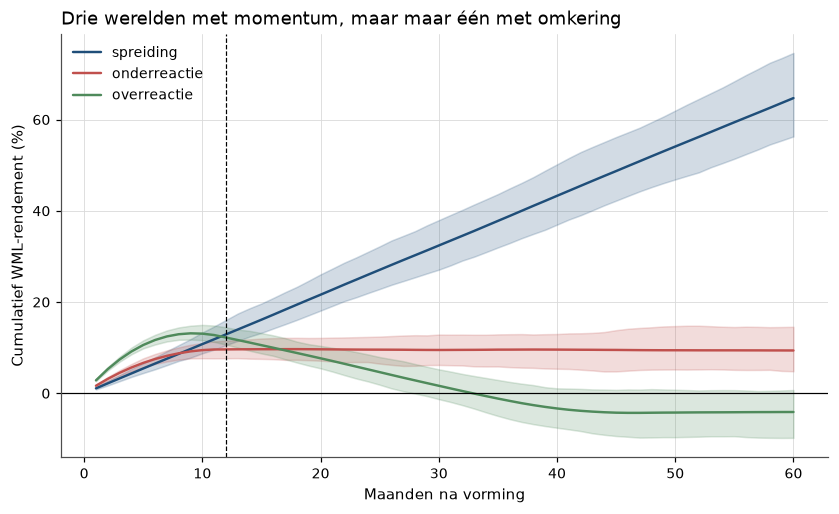

In [6]:
fig, ax = plt.subplots()
months = np.arange(1, HORIZON + 1)
for i, (name, x) in enumerate(event.items()):
    cum = 100 * x.cumsum(axis=1)
    ax.plot(months, cum.mean(axis=0), color=hap.plotting.COLORS[i], label=name)
    ax.fill_between(months, *np.percentile(cum, [5, 95], axis=0), color=hap.plotting.COLORS[i], alpha=0.2)
ax.axvline(12, color="black", lw=0.8, ls="--")
ax.axhline(0, color="black", lw=0.8)
ax.set_xlabel("Maanden na vorming")
ax.set_ylabel("Cumulatief WML-rendement (%)")
ax.set_title("Drie werelden met momentum, maar maar één met omkering")
ax.legend()
plt.show()

:::{figure} #cel-momentum-sim-a
:label: fig-momentum-sim-a
:width: 90%

Alle drie de werelden leveren in het eerste jaar ongeveer een procent per maand. Daarna
lopen ze uiteen: bij spreiding in verwachte rendementen blijven de winnaars voor altijd
winnen, bij zuivere onderreactie vlakt de lijn af, en alleen overreactie maakt van
winnaars verliezers. De banden zijn het 5e en 95e percentiel over 100 steekproeven van
25 jaar.
:::

De simulatie geeft {prf:ref}`cor-momentum-horizon` een vorm. Alle drie de werelden
verdienen in het eerste jaar 0,8 tot 1,1% per maand. In maand 13–60 verdient de
spreidingswereld even veel (1,08%), is de onderreactiewereld op nul (−0,005%, in 54% van
de steekproeven negatief) en verliest alleen de overreactiewereld (−0,34%, in elke
steekproef negatief). Dat de omkering van Jegadeesh en Titman na 1982 zwakker was, kan
dus een verschuiving van overreactie naar onderreactie zijn, of een overreactie die
in zeventien jaar niet scherp te zien is: de spreiding over steekproeven (0,06–0,09
procentpunt) geldt voor 500 aandelen met een eenvoudige factorstructuur, en echte
WML-rendementen zijn veel ruiziger.

### (b) Volatility scaling in 85-jarige steekproeven

Nu één factor met GARCH-volatiliteit {cite}`Bollerslev1986`: dagrendementen
$r_d = \mu_d + \sqrt{h_d}\,z_d$ met $h_{d+1} = \omega + 0{,}15\,(r_d-\mu_d)^2 + 0{,}84\,h_d$,
een onvoorwaardelijke volatiliteit van 16% en een Sharpe-ratio van 0,5 per jaar, over 85
jaar van 21 handelsdagen per maand. We toetsen de drie gevallen van
{prf:ref}`cor-momentum-schalen` met hetzelfde pad van schokken: constant $\mu_d$,
$\mu_d \propto \sqrt{h_d}$ en $\mu_d \propto h_d$. Elke maand schalen we zoals Barroso en
Santa-Clara: 12% gedeeld door de volatiliteit uit de 126 voorgaande dagen.

In [7]:
YEARS, DAYS, N_PATHS = 85, 21, 1000
ALPHA_G, BETA_G, VOL_ANN, SR_ANN, TARGET = 0.15, 0.84, 0.16, 0.5, 0.12
var_d = VOL_ANN**2 / 252
mu_d = SR_ANN * VOL_ANN / 252
n_months = 12 * YEARS

acc = {k: np.zeros((n_months, N_PATHS)) for k in ("shock", "h", "sqrt_h", "rv")}
h = np.full(N_PATHS, var_d)
for m in range(n_months):
    for _ in range(DAYS):
        shock = np.sqrt(h) * rng.standard_normal(N_PATHS)
        acc["shock"][m] += shock
        acc["h"][m] += h
        acc["sqrt_h"][m] += np.sqrt(h)
        acc["rv"][m] += shock**2
        h = var_d * (1 - ALPHA_G - BETA_G) + ALPHA_G * shock**2 + BETA_G * h

monthly = {"constant mu": mu_d * DAYS + acc["shock"],
           "mu evenredig met sigma": mu_d * acc["sqrt_h"] / np.sqrt(var_d) + acc["shock"],
           "mu evenredig met sigma^2": mu_d * acc["h"] / var_d + acc["shock"]}
rv_126 = pd.DataFrame(acc["rv"]).rolling(6).sum().to_numpy()
weight = TARGET / np.sqrt(rv_126[5:-1] * 252 / 126)            # known at the end of the previous month


def ann_sharpe(x):
    """Annualised Sharpe ratio per column."""
    return np.sqrt(12) * x.mean(axis=0) / x.std(axis=0, ddof=1)


sr = {name: (ann_sharpe(x[6:]), ann_sharpe(weight * x[6:])) for name, x in monthly.items()}
pd.DataFrame(
    {name: {"SR ongeschaald (gem.)": a.mean(), "SR ongeschaald (SD)": a.std(),
            "SR geschaald (gem.)": b.mean(), "SR geschaald (SD)": b.std(),
            "winst (gem.)": (b - a).mean(), "winst (SD)": (b - a).std(),
            "fractie winst < 0": (b < a).mean()}
     for name, (a, b) in sr.items()}
).T.round(3)

,SR ongeschaald (gem.),SR ongeschaald (SD),SR geschaald (gem.),SR geschaald (SD),winst (gem.),winst (SD),fractie winst < 0
constant mu,0.535,0.137,0.647,0.119,0.112,0.081,0.026
mu evenredig met sigma,0.427,0.119,0.468,0.114,0.041,0.065,0.268
mu evenredig met sigma^2,0.461,0.105,0.432,0.113,-0.030,0.055,0.748


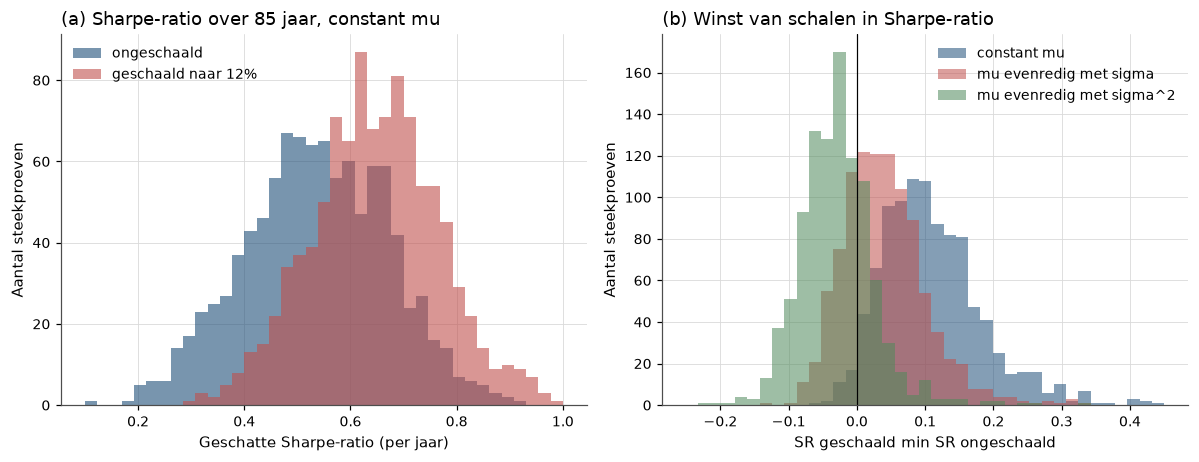

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.3))
bins = np.linspace(0.1, 1.0, 40)
a, b = sr["constant mu"]
axes[0].hist(a, bins=bins, alpha=0.6, label="ongeschaald")
axes[0].hist(b, bins=bins, alpha=0.6, label="geschaald naar 12%")
axes[0].set_title("(a) Sharpe-ratio over 85 jaar, constant mu")
axes[0].set_xlabel("Geschatte Sharpe-ratio (per jaar)")
axes[0].set_ylabel("Aantal steekproeven")
axes[0].legend()
bins = np.linspace(-0.25, 0.45, 40)
for i, (name, (a, b)) in enumerate(sr.items()):
    axes[1].hist(b - a, bins=bins, alpha=0.55, color=hap.plotting.COLORS[i], label=name)
axes[1].axvline(0, color="black", lw=0.8)
axes[1].set_title("(b) Winst van schalen in Sharpe-ratio")
axes[1].set_xlabel("SR geschaald min SR ongeschaald")
axes[1].set_ylabel("Aantal steekproeven")
axes[1].legend()
fig.tight_layout()
plt.show()

:::{figure} #cel-momentum-sim-b
:label: fig-momentum-sim-b
:width: 100%

Links: over 85 jaar is de Sharpe-ratio zelf slecht gemeten, met een standaardfout van
ruwweg 0,1. Rechts: de *winst* van schalen, gemeten op hetzelfde pad, is veel
nauwkeuriger, en haar teken hangt af van hoe het verwachte rendement met de
volatiliteit meebeweegt. Schalen wint bij een constant verwacht rendement, en verliest
als het verwachte rendement evenredig met de variantie is.
:::

Drie dingen vallen op. Het eerste is motief 1: de Sharpe-ratio van één 85-jarige
steekproef heeft een standaarddeviatie van 0,11 tot 0,14, dus twee losse schattingen van
0,53 en 0,97 zouden elk weinig overtuigen. Het tweede is dat de *winst* van schalen
gepaard wordt gemeten, op dezelfde schokken, en daardoor nauwkeuriger is: bij een
constant verwacht rendement gemiddeld 0,11 met een standaarddeviatie van 0,08, en in
maar 2,6% van de steekproeven negatief. Het derde is het teken: bij $\mu \propto \sigma$
is de winst 0,04, bij $\mu \propto \sigma^2$ −0,03 (in 75% van de steekproeven negatief),
zoals {prf:ref}`cor-momentum-schalen` voorspelt. Een verdubbeling zit er in deze
GARCH-wereld niet in: ze heeft minder *vol-of-vol* (variatie in de volatiliteit zelf)
dan momentum, en geen negatief verband tussen volatiliteit en verwacht rendement.

## Replicatie op echte data

We gebruiken de momentumportefeuilles van French: tien waardegewogen en tien
gelijkgewogen decielen op prior 12-2 (maand en dag), de zes size-momentumportefeuilles
waaruit UMD is gebouwd, de UMD-factor zelf, en de FF3-factoren.

In [9]:
ff3 = hap_data.french("F-F_Research_Data_Factors")
umd = hap_data.french("F-F_Momentum_Factor")["Mom"]
umd_daily = hap_data.french("F-F_Momentum_Factor", "daily")["Mom"]
dec_vw = hap_data.french("10_Portfolios_Prior_12_2")
dec_ew = hap_data.french("10_Portfolios_Prior_12_2", table="Equal Weight")
dec_vw_daily = hap_data.french("10_Portfolios_Prior_12_2", "daily")
six = hap_data.french("6_Portfolios_ME_Prior_12_2")

wml_vw = (dec_vw["Hi PRIOR"] - dec_vw["Lo PRIOR"]).rename("WML vw")
wml_ew = (dec_ew["Hi PRIOR"] - dec_ew["Lo PRIOR"]).rename("WML ew")
wml_vw_daily = dec_vw_daily["Hi PRIOR"] - dec_vw_daily["Lo PRIOR"]
umd_from_six = 0.5 * (six["SMALL HiPRIOR"] + six["BIG HiPRIOR"]) - 0.5 * (six["SMALL LoPRIOR"] + six["BIG LoPRIOR"])

print(hap_data.french_tables("6_Portfolios_ME_Prior_12_2")[["title", "nobs"]].head(2).to_string())
print(f"max |UMD uit zes portefeuilles - UMD| = {(umd_from_six - umd).abs().max():.5f}")

                                                title  nobs
date                                                       
2000-01-01  Average Value Weighted Returns -- Monthly  1195
2000-01-01  Average Equal Weighted Returns -- Monthly  1195
max |UMD uit zes portefeuilles - UMD| = 0.00010


UMD is tot op afronding van de gepubliceerde procenten precies
[](#eq-momentum-umd) toegepast op de zes portefeuilles.

### Jegadeesh-Titman: 1965–1989 en daarna

```{admonition} Replicatie
:class: seealso

**Bron.** Narasimhan Jegadeesh en Sheridan Titman, *Returns to Buying Winners and
Selling Losers: Implications for Stock Market Efficiency*, Journal of Finance 1993
{cite}`JegadeeshTitman1993`; idem, *Profitability of Momentum Strategies*, Journal of
Finance 2001 {cite}`JegadeeshTitman2001`; Fama en French 1996 {cite}`FamaFrench1996`.

**Wat.** Tabel I van JT (1993): het buy-min-sell-rendement over 1965–1989, zoals 0,0131
($t = 3{,}74$) voor 12/3; het out-of-sample-rendement over 1990–1998 (1,39% per maand)
uit JT (2001); en de bewering van FF (1996) dat het driefactormodel de voortzetting niet
verklaart.

**Data hier.** Kenneth French Data Library: decielen op prior 12-2, gelijk- en
waardegewogen, UMD en FF3, maandelijks, via `hap.data.french(...)`.

**Verschil met het origineel.** JT gebruikten NYSE- en AMEX-aandelen en overlappende
J/K-portefeuilles; French' decielen worden elke maand op 12-2 gevormd met
NYSE-breekpunten en één maand aangehouden ($J = 11$, $K = 1$, een maand sprong), met
minder kleine aandelen in de extreme decielen.

**Verwachte afwijking.** Een gemiddeld WML-rendement van ruwweg 1 à 1,5% per maand met
$t > 3$ over 1965–1989; een CAPM-alfa van dezelfde grootte (de bèta van WML is gemiddeld
bijna nul); een FF3-alfa die *groter* is dan het ruwe rendement, omdat WML negatief laadt
op SMB en HML; een negatief gemiddelde in januari. Wijkt het teken van één daarvan af,
dan zit er een fout in de code.
```

In [10]:
def nw_alpha(y, factors=None, lags=6):
    """Intercept (in % per month), Newey-West t-value and slopes of y on factors."""
    X = pd.DataFrame(index=y.index) if factors is None else factors
    fit = hap.stats.newey_west(y, X, lags=lags)
    return 100 * fit.params.iloc[0], fit.tvalues.iloc[0], fit.params.iloc[1:]


def jt_row(y, start, end):
    """Mean, CAPM and FF3 alphas with NW t-values over [start, end]."""
    y = y.loc[start:end]
    X = ff3.loc[start:end]
    mean, t_mean, _ = nw_alpha(y)
    a_capm, t_capm, b_capm = nw_alpha(y, X[["Mkt-RF"]])
    a_ff3, t_ff3, b_ff3 = nw_alpha(y, X[["Mkt-RF", "SMB", "HML"]])
    return {"gem. (%/mnd)": mean, "t": t_mean, "CAPM-alfa": a_capm, "t(CAPM)": t_capm,
            "bèta markt": b_capm["Mkt-RF"], "FF3-alfa": a_ff3, "t(FF3)": t_ff3,
            "bèta SMB": b_ff3["SMB"], "bèta HML": b_ff3["HML"]}


series = {"deciel 10-1 gelijkgewogen": wml_ew, "deciel 10-1 waardegewogen": wml_vw, "UMD": umd}
pd.DataFrame({name: jt_row(y, "1965-01", "1989-12") for name, y in series.items()}).T.round(3)

,gem. (%/mnd),t,CAPM-alfa,t(CAPM),bèta markt,FF3-alfa,t(FF3),bèta SMB,bèta HML
deciel 10-1 gelijkgewogen,1.331,5.497,1.341,5.717,-0.027,1.687,7.691,-0.504,-0.414
deciel 10-1 waardegewogen,1.640,5.347,1.657,5.341,-0.048,1.913,6.460,-0.285,-0.345
UMD,0.821,4.319,0.816,4.264,0.014,1.002,5.343,-0.133,-0.283


In [11]:
periods = {"1927-1964": ("1927-01", "1964-12"), "1965-1989 (JT)": ("1965-01", "1989-12"),
           "1990-1998 (JT 2001)": ("1990-01", "1998-12"), "1999-2026": ("1999-01", "2026-12")}
rows = {}
for label, (a, b) in periods.items():
    for name, y in series.items():
        mean, t_mean, _ = nw_alpha(y.loc[a:b])
        rows[(label, name)] = {"gem. (%/mnd)": mean, "t": t_mean}
jan = wml_ew.loc["1965":"1989"]
rows[("1965-1989, januari", "deciel 10-1 gelijkgewogen")] = {
    "gem. (%/mnd)": 100 * jan[jan.index.month == 1].mean(), "t": np.nan}
rows[("1965-1989, overige maanden", "deciel 10-1 gelijkgewogen")] = {
    "gem. (%/mnd)": 100 * jan[jan.index.month != 1].mean(), "t": np.nan}
pd.DataFrame(rows).T.round(3)

gem. (%/mnd)      t
1927-1964                  deciel 10-1 gelijkgewogen         0.684  1.725
                           deciel 10-1 waardegewogen         1.081  2.941
                           UMD                               0.638  2.740
1965-1989 (JT)             deciel 10-1 gelijkgewogen         1.331  5.497
                           deciel 10-1 waardegewogen         1.640  5.347
                           UMD                               0.821  4.319
1990-1998 (JT 2001)        deciel 10-1 gelijkgewogen         1.107  2.740
                           deciel 10-1 waardegewogen         1.751  3.551
                           UMD                               1.004  3.480
1999-2026                  deciel 10-1 gelijkgewogen         0.544  1.158
                           deciel 10-1 waardegewogen         0.597  1.159
                           UMD                               0.280  0.978
1965-1989, januari         deciel 10-1 gelijkgewogen        -5.262    NaN
1965-1989, overige maanden deciel 10-1 gelijkgewogen         1.930    NaN

Over 1965–1989 verdient het gelijkgewogen decielverschil 1,33% per maand (Newey-West
$t = 5{,}50$), dicht bij de 0,0131 van 12/3 in tabel I van Jegadeesh en Titman. De
CAPM-bèta is −0,03, dus de CAPM-alfa is het ruwe rendement. De FF3-alfa is met 1,69%
*hoger*: WML laadt negatief op SMB (−0,50) en HML (−0,41), omdat de winnaars in deze
periode grotere groeiaandelen waren. Het driefactormodel verklaart momentum dus niet
alleen niet, het maakt het raadsel groter. Ook het januari-patroon is er: in januari
verliest de strategie gemiddeld 5,3%, in de andere maanden verdient ze 1,93%. Over
1990–1998 blijft de premie (1,11% gelijk- en 1,75% waardegewogen), zoals Jegadeesh en
Titman in 2001 rapporteerden. Na 1999 is het gemiddelde 0,54% met $t = 1{,}16$. Dat is
motief 1: met een maandelijkse volatiliteit van 7,7% is een kwarteeuw niet genoeg om een
halve procent per maand van nul te onderscheiden.

### Barroso-Santa-Clara: momentum heeft zijn momenten

```{admonition} Replicatie
:class: seealso

**Bron.** Pedro Barroso en Pedro Santa-Clara, *Momentum Has Its Moments*, Journal of
Financial Economics 2015 {cite}`BarrosoSantaClara2015`.

**Wat.** Tabel 3: gemiddelde, standaarddeviatie, Sharpe-ratio, excess kurtosis,
scheefheid, slechtste en beste maand van WML en van WML geschaald naar 12% doelvolatiliteit,
1927:03–2011:12. Gepubliceerd: Sharpe-ratio 0,53 → 0,97, kurtosis 18,24 → 2,68,
scheefheid −2,47 → −0,42, slechtste maand −78,96% → −28,40%; maximale *drawdown*
(grootste val vanaf een eerdere top) −96,69% → −45,20%; gemiddeld gewicht 0,90 (bereik
0,13–2,00).

**Data hier.** French' waardegewogen decielen op prior 12-2, maandelijks en dagelijks,
1926-11 t/m 2026-07; WML = deciel 10 min deciel 1.

**Verschil met het origineel.** BSC gebruikten dezelfde French-decielen, maar vóór 1963
dagrendementen van Daniel en Moskowitz; French heeft zijn data sindsdien herzien. Onze
eerste variantieschatting vraagt 126 dagen vanaf november 1926, dus we beginnen in
1927:05.

**Verwachte afwijking.** Sharpe-ratio's binnen 0,05 van de gepubliceerde; een
geschaalde strategie met ongeveer verdubbelde Sharpe-ratio, scheefheid dicht bij nul,
een kurtosis die met een factor vijf of meer daalt en een drawdown die ongeveer halveert.
Het tot heden verlengde resultaat moet kwalitatief gelijk zijn.
```

In [12]:
var_forecast = (wml_vw_daily**2).rolling(126).sum() * 21 / 126
var_forecast = var_forecast.groupby(wml_vw_daily.index.to_period("M")).last().to_timestamp("M")
sigma_hat = np.sqrt(12 * var_forecast)                              # annualised, known at month end
bsc = pd.concat([wml_vw, (TARGET / sigma_hat).shift(1).rename("gewicht"),
                 sigma_hat.shift(1).rename("sigma_hat")], axis=1, sort=True).dropna()
bsc["WML geschaald"] = bsc["gewicht"] * bsc["WML vw"]


def bsc_table(x):
    """Statistics of Barroso and Santa-Clara (2015), Table 3, plus maximum drawdown."""
    return {"gemiddelde (%/jaar)": 1200 * x.mean(), "SD (%/jaar)": 100 * np.sqrt(12) * x.std(),
            "Sharpe-ratio": np.sqrt(12) * x.mean() / x.std(), "excess kurtosis": x.kurtosis(),
            "scheefheid": x.skew(), "slechtste maand (%)": 100 * x.min(), "beste maand (%)": 100 * x.max(),
            "max drawdown (%)": 100 * hap.stats.drawdowns(x).attrs["max_drawdown"]}


sample = bsc.loc[:"2011-12"]
ours = {"WML (hier)": bsc_table(sample["WML vw"]), "geschaald (hier)": bsc_table(sample["WML geschaald"]),
        "WML tot 2026": bsc_table(bsc["WML vw"]), "geschaald tot 2026": bsc_table(bsc["WML geschaald"])}
paper = {"WML (BSC)": [14.46, 27.53, 0.53, 18.24, -2.47, -78.96, 26.18, -96.69],
         "geschaald (BSC)": [16.50, 16.95, 0.97, 2.68, -0.42, -28.40, 21.95, -45.20]}
paper = {k: dict(zip(ours["WML (hier)"], v)) for k, v in paper.items()}
table3 = pd.DataFrame({k: {**ours, **paper}[k] for k in
                       ["WML (hier)", "WML (BSC)", "geschaald (hier)", "geschaald (BSC)", "WML tot 2026", "geschaald tot 2026"]})
print(f"steekproef {sample.index[0]:%Y-%m} t/m {sample.index[-1]:%Y-%m}, {len(sample)} maanden; "
      f"gewicht gem. {sample['gewicht'].mean():.2f}, min {sample['gewicht'].min():.2f}, max {sample['gewicht'].max():.2f}; "
      f"SD log sigma_hat {np.log(bsc['sigma_hat']).std():.2f}")
table3.round(2)

steekproef 1927-05 t/m 2011-12, 1016 maanden; gewicht gem. 0.90, min 0.14, max 2.09; SD log sigma_hat 0.55


,WML (hier),WML (BSC),geschaald (hier),geschaald (BSC),WML tot 2026,geschaald tot 2026
gemiddelde (%/jaar),14.86,14.46,16.69,16.50,13.66,14.95
SD (%/jaar),27.42,27.53,16.77,16.95,27.61,16.22
Sharpe-ratio,0.54,0.53,1.00,0.97,0.49,0.92
excess kurtosis,18.04,18.24,2.01,2.68,15.27,2.05
scheefheid,-2.39,-2.47,-0.36,-0.42,-2.11,-0.30
slechtste maand (%),-77.66,-78.96,-24.16,-28.40,-77.66,-24.16
beste maand (%),26.24,26.18,21.71,21.95,26.24,21.71
max drawdown (%),-95.56,-96.69,-43.83,-45.20,-95.56,-43.83


In [13]:
realized_var = (wml_vw_daily**2).groupby(wml_vw_daily.index.to_period("M")).sum().to_timestamp("M")
pred = pd.concat([realized_var.rename("RV"), (var_forecast.shift(1) * 12).rename("voorspelling"),
                  wml_vw.rename("WML")], axis=1, sort=True).dropna().loc[:"2011-12"]
pd.DataFrame({
    "R^2 gerealiseerde variantie op voorspelling": [sm.OLS(pred["RV"], sm.add_constant(pred["voorspelling"])).fit().rsquared],
    "R^2 WML-rendement op voorspelling": [sm.OLS(pred["WML"], sm.add_constant(pred["voorspelling"])).fit().rsquared],
    "helling WML op voorspelling": [sm.OLS(pred["WML"], sm.add_constant(pred["voorspelling"])).fit().params.iloc[1]],
    "t (NW)": [hap.stats.newey_west(pred["WML"], pred[["voorspelling"]]).tvalues.iloc[1]],
}, index=["1927-2011"]).T.round(3)

,1927-2011
R^2 gerealiseerde variantie op voorspelling,0.368
R^2 WML-rendement op voorspelling,0.016
helling WML op voorspelling,-0.108
t (NW),-1.943


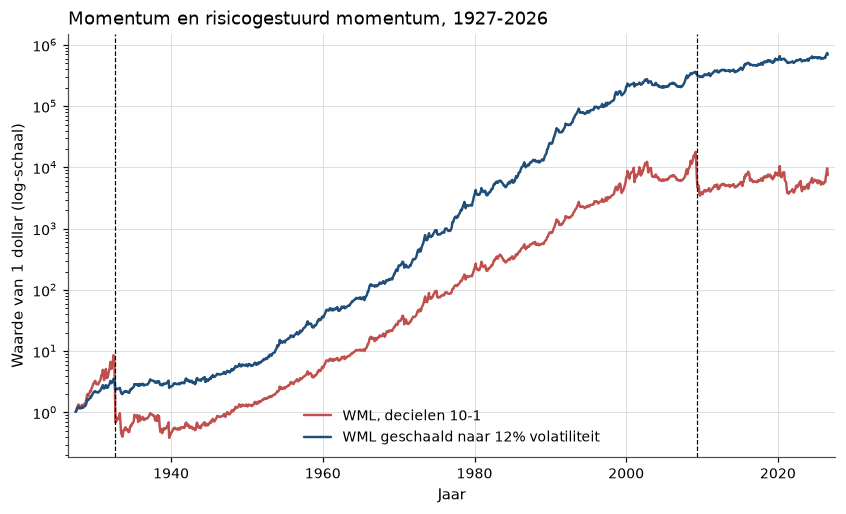

In [14]:
fig, ax = plt.subplots()
for column, color in (("WML vw", hap.plotting.COLORS[1]), ("WML geschaald", hap.plotting.COLORS[0])):
    wealth = hap.stats.drawdowns(bsc[column])["wealth"]
    ax.plot(wealth.index, wealth, color=color,
            label="WML, decielen 10-1" if column == "WML vw" else "WML geschaald naar 12% volatiliteit")
ax.set_yscale("log")
for crash in ("1932-08", "2009-05"):
    ax.axvline(pd.Timestamp(crash), color="black", lw=0.8, ls="--")
hap.plotting.timeline_axis(ax)
ax.set_xlabel("Jaar")
ax.set_ylabel("Waarde van 1 dollar (log-schaal)")
ax.set_title("Momentum en risicogestuurd momentum, 1927-2026")
ax.legend()
plt.show()

:::{figure} #cel-momentum-bsc
:label: fig-momentum-bsc
:width: 90%

De ongeschaalde strategie verliest in 1932 en in 2009 het grootste deel van haar waarde
(stippellijnen). De geschaalde strategie had haar blootstelling vóór beide crashes al
verlaagd, omdat de volatiliteit van momentum toen al hoog was, en eindigt ordes van
grootte hoger met een lagere volatiliteit.
:::

De replicatie komt dicht bij tabel 3. De Sharpe-ratio stijgt van 0,54 naar 1,00 (BSC:
0,53 naar 0,97), de excess kurtosis daalt van 18,04 naar 2,01 (18,24 naar 2,68), de
scheefheid van −2,39 naar −0,36 (−2,47 naar −0,42), en de maximale drawdown van −95,6%
naar −43,8% (−96,69% naar −45,20%). Ook het gewicht klopt: gemiddeld 0,90, tussen 0,14
en 2,09. Verlengd tot 2026 blijft het beeld staan (0,49 naar 0,92). De voorspelbaarheid
is die van motief 1: de voorspelde variantie verklaart 36,8% van de variatie in de
gerealiseerde variantie en 1,6% van die in het rendement. De helling van het rendement op
de voorspelde variantie is negatief ($t = -1{,}94$): als momentum riskant is, is het
verwachte rendement eerder lager, het tegendeel van geval 3 in
{prf:ref}`cor-momentum-schalen` en de reden dat de winst groter is dan in de simulatie.

### Daniel-Moskowitz: de crashes van 1932 en 2009

```{admonition} Replicatie
:class: seealso

**Bron.** Kent Daniel en Tobias J. Moskowitz, *Momentum Crashes*, Journal of Financial
Economics 2016 {cite}`DanielMoskowitz2016`.

**Wat.** De episodes juli–augustus 1932 (verliezers +232%, winnaars +32%) en maart–mei
2009 (verliezers +163%, winnaars +8%), en de optie-achtige bèta: in bear markets een
bèta van WML van −0,70 in dalende en −1,51 in stijgende maanden (1927:01–2013:03).

**Data hier.** French' waardegewogen decielen op prior 12-2 en de FF3-marktfactor. Bear
market: cumulatief marktrendement (Mkt-RF + RF) over de 24 maanden tot en met $t-1$
negatief. Stijgende maand: excess marktrendement in maand $t$ positief.

**Verschil met het origineel.** DM gebruikten CRSP-decielen en de CRSP-index; wij
French' versies van beide, in een regressie van dezelfde vorm.

**Verwachte afwijking.** Cumulatieve rendementen van de decielen binnen enkele
procentpunten van de gepubliceerde; in bear markets een negatieve bèta, die in stijgende
maanden duidelijk negatiever is dan in dalende; buiten bear markets een bèta rond nul.
```

In [15]:
episodes = {"1932-07 t/m 1932-08": ("1932-07", "1932-08"), "2009-03 t/m 2009-05": ("2009-03", "2009-05")}
market = ff3["Mkt-RF"] + ff3["RF"]
pd.DataFrame(
    {label: {"verliezers (deciel 1)": 100 * ((1 + dec_vw["Lo PRIOR"].loc[a:b]).prod() - 1),
             "winnaars (deciel 10)": 100 * ((1 + dec_vw["Hi PRIOR"].loc[a:b]).prod() - 1),
             "WML": 100 * ((1 + wml_vw.loc[a:b]).prod() - 1),
             "markt": 100 * ((1 + market.loc[a:b]).prod() - 1),
             "markt, 24 maanden ervoor": 100 * ((1 + market.loc[:a].iloc[-25:-1]).prod() - 1)}
     for label, (a, b) in episodes.items()}
).round(1)

,1932-07 t/m 1932-08,2009-03 t/m 2009-05
verliezers (deciel 1),239.1,158.5
winnaars (deciel 10),30.8,7.2
WML,-91.6,-73.8
markt,83.3,26.4
"markt, 24 maanden ervoor",-74.7,-44.8


In [16]:
dm = pd.concat([wml_vw, ff3["Mkt-RF"], np.expm1(np.log1p(market).rolling(24).sum()).shift(1).rename("markt 24m")],
               axis=1, sort=True).dropna()
dm["bear"] = (dm["markt 24m"] < 0).astype(float)
dm["up"] = (dm["Mkt-RF"] > 0).astype(float)
design = pd.DataFrame({"bear": dm["bear"], "markt": dm["Mkt-RF"], "bear x markt": dm["bear"] * dm["Mkt-RF"],
                       "bear x up x markt": dm["bear"] * dm["up"] * dm["Mkt-RF"]})


def dm_betas(end):
    """Daniel-Moskowitz regression of WML on market with bear and bear-up interactions."""
    fit = hap.stats.newey_west(dm["WML vw"].loc[:end], design.loc[:end], lags=3)
    p = fit.params
    return {"bèta, geen bear market": p["markt"],
            "bèta, bear market, dalende markt": p["markt"] + p["bear x markt"],
            "bèta, bear market, stijgende markt": p["markt"] + p["bear x markt"] + p["bear x up x markt"],
            "t verschil stijgend-dalend": fit.tvalues["bear x up x markt"],
            "gem. WML in bear market (%/mnd)": 100 * dm["WML vw"].loc[:end][dm["bear"].loc[:end] == 1].mean(),
            "gem. WML buiten bear market (%/mnd)": 100 * dm["WML vw"].loc[:end][dm["bear"].loc[:end] == 0].mean(),
            "maanden in bear market": int(dm["bear"].loc[:end].sum())}


worst = wml_vw.nsmallest(15)
print(f"van de 15 slechtste WML-maanden kwamen er {int((dm.loc[worst.index, 'bear'] == 1).sum())} na een negatief tweejaarsrendement")
pd.DataFrame({"1927-2013:03 (DM)": dm_betas("2013-03"), "1927-2026": dm_betas("2026-12")}).round(3)

van de 15 slechtste WML-maanden kwamen er 11 na een negatief tweejaarsrendement


,1927-2013:03 (DM),1927-2026
"bèta, geen bear market",-0.005,-0.052
"bèta, bear market, dalende markt",-0.695,-0.698
"bèta, bear market, stijgende markt",-1.406,-1.422
t verschil stijgend-dalend,-2.104,-2.190
gem. WML in bear market (%/mnd),-0.851,-1.110
gem. WML buiten bear market (%/mnd),1.656,1.559
maanden in bear market,183.000,191.000


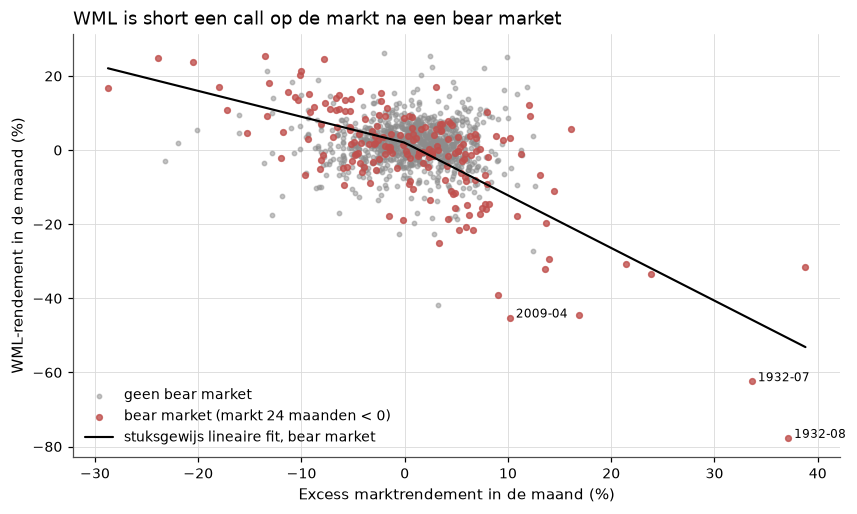

In [17]:
fig, ax = plt.subplots()
calm, bear = dm[dm["bear"] == 0], dm[dm["bear"] == 1]
ax.scatter(100 * calm["Mkt-RF"], 100 * calm["WML vw"], s=8, color=hap.plotting.COLORS[7], alpha=0.5,
           label="geen bear market")
ax.scatter(100 * bear["Mkt-RF"], 100 * bear["WML vw"], s=14, color=hap.plotting.COLORS[1], alpha=0.8,
           label="bear market (markt 24 maanden < 0)")
fit = sm.OLS(bear["WML vw"], sm.add_constant(pd.DataFrame(
    {"m": bear["Mkt-RF"], "m_up": bear["Mkt-RF"] * bear["up"]}))).fit()
grid = np.linspace(bear["Mkt-RF"].min(), bear["Mkt-RF"].max(), 100)
ax.plot(100 * grid, 100 * (fit.params["const"] + fit.params["m"] * grid + fit.params["m_up"] * np.maximum(grid, 0)),
        color="black", lw=1.4, label="stuksgewijs lineaire fit, bear market")
for date in ("1932-07-31", "1932-08-31", "2009-04-30"):
    ax.annotate(date[:7], (100 * dm.loc[date, "Mkt-RF"], 100 * dm.loc[date, "WML vw"]), fontsize=8,
                xytext=(4, 0), textcoords="offset points")
ax.set_xlabel("Excess marktrendement in de maand (%)")
ax.set_ylabel("WML-rendement in de maand (%)")
ax.set_title("WML is short een call op de markt na een bear market")
ax.legend()
plt.show()

:::{figure} #cel-momentum-crash
:label: fig-momentum-crash
:width: 90%

In gewone tijden (grijs) heeft WML nauwelijks marktbèta. Na een negatief
tweejaarsrendement van de markt (rood) is de bèta negatief, en in stijgende maanden
veel negatiever dan in dalende: de knik van een geschreven call. De drie slechtste
maanden in de geschiedenis van momentum liggen rechtsonder.
:::

De episodes kloppen tot op enkele procentpunten: in juli–augustus 1932 steeg het
verliezersdeciel 239% en het winnaarsdeciel 31% (DM: 232% en 32%), in maart–mei 2009
159% en 7% (163% en 8%). WML verloor 91,6% en 73,8% (BSC: −91,59% en −73,42%), na 24
maanden waarin de markt 75% en 45% was gedaald. Elf van de vijftien slechtste maanden
kwamen na een negatief tweejaarsrendement; DM telden er veertien, met CRSP-decielen en de
CRSP-index, wat de rangorde van de slechtste maanden verschuift. De regressie over
1927–2013:03 geeft buiten bear markets een bèta van −0,01 en in bear markets −0,70 in
dalende en −1,41 in stijgende maanden ($|t| = 2{,}1$ voor het verschil); DM vonden −0,70
en −1,51. Teken en asymmetrie zijn die van {prf:ref}`prop-momentum-beta` en de
optie-interpretatie. Bovendien verdient WML in bear markets gemiddeld −0,85% per maand,
tegen 1,66% daarbuiten: in de meest volatiele toestanden is momentum ook minder
winstgevend.

## Wat er brak, en wat daarna kwam

**Wat het model verklaart.** Momentum is misschien het best gerepliceerde feit uit dit
tijdvak. Het overleefde de nieuwe steekproef van {cite:t}`JegadeeshTitman2001`, twaalf
Europese landen, waar een internationaal gespreide winnaarsportefeuille over 1980–1995
na correctie voor risico meer dan een procent per maand beter deed dan de
verliezersportefeuille {cite}`Rouwenhorst1998`, en industrieën, waar
{cite:t}`MoskowitzGrinblatt1999` een gelijkgewogen industriemomentum van 10,2% per jaar
vonden ($t = 7{,}71$) dat een groot deel van het aandelenmomentum verklaart.
{cite:t}`AsnessMoskowitzPedersen2013` vonden value en momentum in acht markten
tegelijk: aandelen in de VS, het VK, Europa en Japan, landenindices, obligaties,
valuta en grondstoffen. Binnen aandelenmarkten was de correlatie tussen value en
momentum gemiddeld ongeveer −0,60, en een 50/50-combinatie over alle activaklassen had een
Sharpe-ratio van 1,45. Het vierfactormodel van Carhart werd de meetlat voor beheerders,
en in de werkversie van *Dissecting Anomalies* schreven Fama en French: "The premier
anomaly is momentum" {cite}`FamaFrench2008`. Santa-Clara noemt het in zijn terugblik de
anomalie die de efficiënte markt blijft beschamen {cite}`SantaClara2026`.

**Waar het breekt.** Theoretisch: geen evenwichtsmodel voorspelde momentum, en het
driefactormodel maakt het erger; onze FF3-alfa over 1965–1989 is 1,69% per maand, hoger
dan het ruwe rendement. Praktisch: de premie komt met crashes van −91,6% in twee maanden
(1932) en −73,8% in drie maanden (2009), te voorspellen uit de marktstand en de eigen
volatiliteit. Dat risicogestuurd momentum een Sharpe-ratio van ongeveer één heeft,
maakt het raadsel groter. Barroso en Santa-Clara: "Risk-managed momentum is a much
greater puzzle than the original version."

**Risico of vergissing?** De gedragslezing heeft drie modellen die alle drie een
voortzetting op middellange en een omkering op lange termijn voorspellen. In
{cite:t}`BarberisShleiferVishny1998` reageren beleggers conservatief op losse
aankondigingen (onderreactie) en extrapoleren ze reeksen goed nieuws (overreactie). In
{cite:t}`DanielHirshleiferSubrahmanyam1998` zijn beleggers overmoedig over hun eigen
informatie en wordt die overmoed groter als het publieke nieuws hen gelijk lijkt te
geven. In {cite:t}`HongStein1999` verspreidt nieuws zich langzaam onder
nieuwsvolgers, en duwen trendvolgers de koers daarna voorbij de juiste waarde. De
omkering van Jegadeesh en Titman (2001) en de overreactiewereld uit onze simulatie passen
bij die modellen; we komen erop terug in [de lecture over behavioral finance](#04-23-behavioral). De risicolezing bestaat
ook. Bij {cite:t}`BerkGreenNaik1999` veranderen de systematische risico's van een bedrijf
voorspelbaar met zijn investeringen en groeiopties. Bij {cite:t}`Johnson2002` is de
logaritme van de koers convex in de verwachte groeivoet, zodat groeirisico toeneemt met
de groei: winnaars, die vaker positieve groeischokken hadden, zijn dan riskanter en
hebben een hoger verwacht rendement. Daniel en Moskowitz lezen de lage rendementen in
paniektoestanden als een premie op de optie-achtige payoffs van verliezers. Welke data
zouden de lezingen kunnen scheiden? De lange horizon, maar die omkering was na 1982
zwakker. De crashes, maar een risicoverhaal moet dan uitleggen waarom het schalen weg van
die crashes de premie *verhoogt*. Het praktijkmotief van Santa-Clara scherpt de vraag:
wie momentum koopt, draagt dan een beprijsd risico dat kan crashen, of denkt iets te weten
wat de prijs niet weet. De data zeggen niet welke van de twee.

**Wat er daarna kwam.** Als rendementen van aandelen ten opzichte van elkaar
voorspelbaar zijn, is de volgende vraag of het rendement van de markt als geheel
voorspelbaar is, en of dat een tijdvariërende discontovoet of een vergissing is:
[voorspelbaarheid van rendementen](#04-20-voorspelbaarheid).

## Oefeningen

:::{exercise}
:label: ex-momentum-1

**Hoe groot moet de marktbeweging zijn?** Neem {prf:ref}`prop-momentum-beta` met
decielen ($p = 0{,}1$), $\sigma_\beta = 0{,}3$ en een idiosyncratisch
vormingsrendement over elf maanden van $\sigma_E = 0{,}10\sqrt{11}$.

1. Laat zien dat $\beta_{\mathrm{WML}}$ de helft van zijn limiet bereikt bij
   $|F| = \sigma_E/(\sigma_\beta\sqrt3)$ en bereken die $F$.
2. Bereken $\beta_{\mathrm{WML}}$ voor $F = -0{,}4$ en controleer het met een
   Monte-Carlosimulatie van 100 000 aandelen.
3. Vergelijk met de bèta van WML in bear markets uit de replicatie. Wat zegt het
   verschil over de aannames van de propositie?
:::

:::{solution} ex-momentum-1
:class: dropdown

**(1)** Stel $\sigma_\beta|F|/\sqrt{\sigma_\beta^2F^2 + \sigma_E^2} = \tfrac12$. Kwadrateren
geeft $4\sigma_\beta^2F^2 = \sigma_\beta^2F^2 + \sigma_E^2$, dus
$|F| = \sigma_E/(\sigma_\beta\sqrt3)$.

In [18]:
p, sd_beta, sd_E = 0.10, 0.30, 0.10 * np.sqrt(11)
factor = 2 * stats.norm.pdf(stats.norm.ppf(1 - p)) / p


def beta_wml(F):
    """Equation eq-momentum-beta."""
    return factor * sd_beta**2 * F / np.sqrt(sd_beta**2 * F**2 + sd_E**2)


n_mc, F = 100_000, -0.4
beta_i = 1.0 + sd_beta * rng.standard_normal(n_mc)
s = beta_i * F + sd_E * rng.standard_normal(n_mc)
top, bottom = s >= np.quantile(s, 1 - p), s <= np.quantile(s, p)
print(f"halve limiet bij |F| = {sd_E / (sd_beta * np.sqrt(3)):.3f}, limiet = {factor * sd_beta:.3f}")
print(f"bèta WML bij F = -0.4: formule {beta_wml(F):.3f}, Monte Carlo {beta_i[top].mean() - beta_i[bottom].mean():.3f}")

halve limiet bij |F| = 0.638, limiet = 1.053
bèta WML bij F = -0.4: formule -0.358, Monte Carlo -0.357


**(2)–(3)** De halve limiet ligt bij $|F| = 0{,}64$, en bij een marktdaling van 40% geeft
de propositie een bèta van −0,36 (Monte Carlo: −0,36), terwijl de replicatie in bear
markets −0,70 in dalende en −1,41 in stijgende maanden vindt. Het model onderschat de bèta omdat bèta's in de propositie
vastliggen. Na een crash stijgt de bèta van verliezers juist door hun hefboom (de
optie-lezing van Daniel en Moskowitz), en de spreiding in bèta's is dan groter dan 0,3.
De oefening laat zien dat het teken van de WML-bèta mechanisch volgt uit de sortering,
maar de omvang van de crashes niet.
:::

:::{exercise}
:label: ex-momentum-2

**Welke schaling?** Herhaal de Barroso-Santa-Clara-replicatie tot en met 2026 met drie
schalingsregels op de waardegewogen WML: (i) $0{,}12/\hat\sigma_t$ uit 126 dagen, (ii)
$c/\widehat{\mathrm{RV}}_t$ met de gerealiseerde variantie van alleen de vorige maand
(Moreira-Muir), met $c$ zo gekozen dat de gemiddelde blootstelling gelijk is aan die van
(i), en (iii) regel (ii) met een maximale hefboom van 2. Rapporteer Sharpe-ratio,
scheefheid en maximale drawdown, en doe hetzelfde voor UMD met diens eigen dagdata. Is de
keuze van $c$ een vorm van look-ahead?
:::

:::{solution} ex-momentum-2
:class: dropdown

In [19]:
def scaled_versions(monthly, daily):
    """Plain, BSC (126-day vol) and Moreira-Muir (1-month variance, uncapped and capped) versions."""
    by_month = daily.groupby(daily.index.to_period("M"))
    var_126 = (daily**2).rolling(126).sum().groupby(daily.index.to_period("M")).last().to_timestamp("M") * 252 / 126
    rv_1m = (by_month.apply(lambda x: (x**2).sum()) * 12).to_timestamp("M")
    frame = pd.concat([monthly.rename("r"), (0.12 / np.sqrt(var_126)).shift(1).rename("w_bsc"),
                       (1 / rv_1m).shift(1).rename("w_mm")], axis=1, sort=True).dropna()
    frame["w_mm"] *= frame["w_bsc"].mean() / frame["w_mm"].mean()
    out = {"ongeschaald": frame["r"], "BSC 1/sigma": frame["w_bsc"] * frame["r"],
           "MM 1/RV": frame["w_mm"] * frame["r"], "MM 1/RV, hefboom <= 2": frame["w_mm"].clip(upper=2) * frame["r"]}
    return pd.DataFrame({k: {"Sharpe": np.sqrt(12) * v.mean() / v.std(), "scheefheid": v.skew(),
                             "max drawdown": hap.stats.drawdowns(v).attrs["max_drawdown"]}
                         for k, v in out.items()}).T


pd.concat({"WML decielen": scaled_versions(wml_vw, wml_vw_daily), "UMD": scaled_versions(umd, umd_daily)}).round(3)

Sharpe  scheefheid  max drawdown
WML decielen ongeschaald             0.495      -2.111        -0.956
             BSC 1/sigma             0.922      -0.297        -0.438
             MM 1/RV                 0.992       0.748        -0.316
             MM 1/RV, hefboom <= 2   1.000       0.343        -0.283
UMD          ongeschaald             0.453      -3.024        -0.784
             BSC 1/sigma             0.873      -0.417        -0.426
             MM 1/RV                 0.936       0.991        -0.374
             MM 1/RV, hefboom <= 2   0.968       0.124        -0.216

Alle drie de regels verdubbelen ruwweg de Sharpe-ratio van beide reeksen en halen de
negatieve scheefheid weg; de Moreira-Muir-regel maakt haar zelfs positief, en met een
maximale hefboom van 2 blijft dat resultaat staan. De keuze van $c$ gebruikt de hele
steekproef, maar een constante schaalfactor verandert Sharpe-ratio en scheefheid niet,
alleen de drawdown. Het resultaat hangt dus niet aan één volatiliteitsschatter: wat telt,
is dat de variantie van momentum voorspelbaar is.
:::

:::{exercise}
:label: ex-momentum-3

**Hoeveel spreiding in verwachte rendementen is nodig?** Neem de spreidingswereld uit
de simulatie zonder factor: $R_{i,t} = \mu_i + \varepsilon_{i,t}$ met
$\mu_i \sim \mathcal{N}(0, \sigma_\mu^2)$ en $\varepsilon_{i,t}$ onafhankelijk met
standaarddeviatie 10% per maand. Het signaal is de som van elf maanden rendement, WML
koopt het bovenste en verkoopt het onderste deciel.

1. Leid af dat $\E[R^{\mathrm{WML}}] = \frac{2\varphi(q_{0{,}1})}{0{,}1}\cdot
   \frac{11\sigma_\mu^2}{\sqrt{121\sigma_\mu^2 + 11\cdot 0{,}01}}$.
2. Welke $\sigma_\mu$ is nodig voor 1% per maand? Wat betekent dat, op jaarbasis, voor
   de spreiding in verwachte rendementen tussen aandelen?
3. Vergelijk met de spreiding die het CAPM zou toelaten bij een spreiding in bèta's van
   0,3 en een marktpremie van 6% per jaar. Wat concludeert u over de verklaring van
   momentum met $\sigma_\mu^2$?
:::

:::{solution} ex-momentum-3
:class: dropdown

**(1)** Het signaal is $s_i = 11\mu_i + \sum \varepsilon$, dus $\Cov(\mu, s) = 11\sigma_\mu^2$
en $\Var(s) = 121\sigma_\mu^2 + 11 \cdot 0{,}01$. Hetzelfde argument als in het bewijs van
{prf:ref}`prop-momentum-beta` geeft
$\E[\mu \mid \text{top}] - \E[\mu \mid \text{bodem}] = 2\frac{\Cov(\mu,s)}{\SD(s)}\frac{\varphi(q)}{p}$.

In [20]:
def dispersion_profit(sd_mu, p=0.10, sd_eps=0.10, months=11):
    """Expected WML return in a world with only cross-sectional dispersion in expected returns."""
    k = 2 * stats.norm.pdf(stats.norm.ppf(1 - p)) / p
    return k * months * sd_mu**2 / np.sqrt(months**2 * sd_mu**2 + months * sd_eps**2)


sd_needed = optimize.brentq(lambda x: dispersion_profit(x) - 0.01, 1e-5, 0.05)
print(f"sigma_mu voor 1% per maand: {sd_needed:.4f} per maand = {12 * sd_needed:.1%} per jaar")
print(f"CAPM-spreiding bij SD(beta) = 0.3 en premie 6%: {0.3 * 0.06:.1%} per jaar")
print(f"WML-rendement bij die CAPM-spreiding: {100 * dispersion_profit(0.3 * 0.06 / 12):.3f}% per maand")

sigma_mu voor 1% per maand: 0.0095 per maand = 11.4% per jaar
CAPM-spreiding bij SD(beta) = 0.3 en premie 6%: 1.8% per jaar
WML-rendement bij die CAPM-spreiding: 0.026% per maand


Er is een cross-sectionele standaarddeviatie van verwachte rendementen van ruim 11% per
jaar nodig. Dat is meer dan zes keer wat het CAPM met realistische bèta's toelaat, en de
bijbehorende WML-premie is dan maar een paar honderdste procent per maand. Een zuiver
$\sigma^2_\mu$-verhaal vraagt dus een spreiding in verwachte rendementen die geen bekend
risicomodel levert, en het voorspelt bovendien geen omkering, terwijl die in
1965–1998 wel werd gevonden. Dat is de rekensom achter de conclusie van Jegadeesh en
Titman in 2001.
:::